In [6]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader



In [7]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [8]:
train_dataset = torchvision.datasets.FashionMNIST('./data/' , download=True , transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST('./data' , download=True , train=False ,transform=transforms.Compose([transforms.ToTensor()]))

In [9]:
import torch.utils


train_loader = torch.utils.data.DataLoader(train_dataset , batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset , batch_size=100)

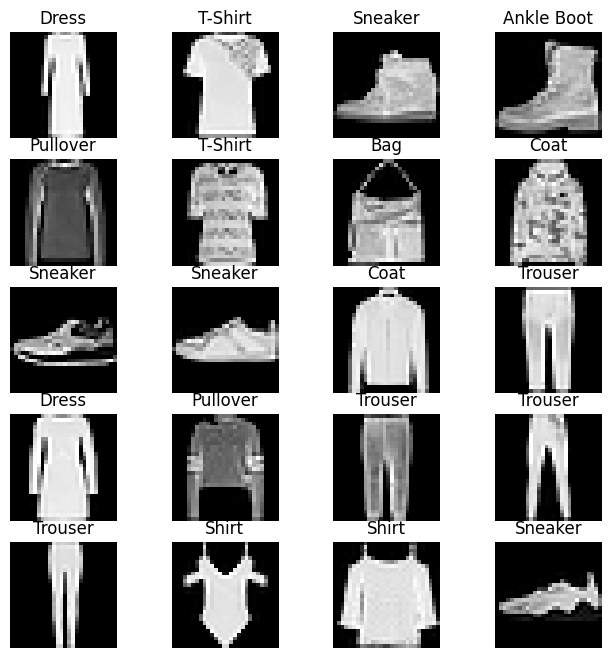

In [10]:
labels_map = { 0 : 'T-Shirt' , 1:'Trouser' ,2: 'Pullover' ,3: 'Dress' ,4:'Coat' , 5: 'Sandal' , 6 : 'Shirt' ,7:'Sneaker' ,8 : 'Bag' ,9 :'Ankle Boot'}

fig = plt.figure(figsize=(8,8))
columns = 4 ;
rows = 5 ;
for i in range(1, columns*rows +1 ):
    img_xy = np.random.randint(len(train_dataset));
    img = train_dataset[img_xy][0][0, : ,:]
    fig.add_subplot(rows , columns , i)
    plt.title(labels_map[train_dataset[img_xy][1]])
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()
    

In [11]:
from turtle import forward


class FashionDNN(nn.Module):
    def __init__(self):
        super(FashionDNN , self).__init__()
        self.fc1 = nn.Linear(in_features=784 , out_features=256)
        self.drop = nn.Dropout(0.25)
        self.fc2 = nn.Linear(in_features=256 , out_features=128)
        self.fc3 = nn.Linear(in_features=128,  out_features=10)
    def forward(self,input_data):
        out = input_data.view(-1,784)
        out = F.relu(self.fc1(out))
        out = self.drop(out)
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out


